In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['NUMEXPR_NUM_THREADS'] = '2'
print("IPython: Thread limits set to 2")

IPython: Thread limits set to 2


#### Dynamic architecture
As the new class is included in the batch, new nodes corresponding to new class are added in the output layer to help compute softmax function. Please refer to the node classification notebook for further details.

Incremental batches: 
- and, not 
- nor 
- nand 
- input 
- output, or 
- xor 


Mechanisms: 
- Naive fine-tuning 
- Rehearsal buffer 
- EWC 
- Synaptic Intelligence (SI) 
- Generative replay 

Applying six search operation for hyperparameter tuning. 
- Grid Search 
- Random Search 
- Bayesian Optimization (surrogate + exploration) 
- Hyperband (successive halving) 
- Population-Based Training (PBT) 
- Evolutionary Algorithm (GA)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
import random, math, time
from copy import deepcopy
import warnings

warnings.filterwarnings("ignore")

# ---------------------------
# Config / globals
# ---------------------------
CSV_PATH = "../all_circuits_features.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_CFG = {
    "epochs_per_task": 50,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "hidden_dim": 64,
    "test_frac": 0.2,
    "seed": 42,
    "max_edges_per_task": 2000,
    "ewc_lam": 1000.0,
    "si_c": 5.0,
    "gat_heads": 4,
    "gat_dropout": 0.0,
}

random.seed(BASE_CFG["seed"])
np.random.seed(BASE_CFG["seed"])
torch.manual_seed(BASE_CFG["seed"])

# ---------------------------
# Load & preprocess data
# ---------------------------
df = pd.read_csv(CSV_PATH)
df["gate_type"] = df["gate_type"].astype(str).str.strip().str.lower()

label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])
classes_found = list(label_encoder.classes_)
class_to_index = {c: i for i, c in enumerate(classes_found)}

feature_columns = [
    "fan_in","fan_out","dist_to_output","is_primary_input","is_primary_output",
    "is_internal","is_key_gate","degree_centrality","betweenness_centrality",
    "closeness_centrality","clustering_coefficient","avg_fan_in_neighbors","avg_fan_out_neighbors"
]
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# Build graph (heuristic)
potential_sources = df[df["fan_out"] > 0]["node"].tolist()
edges = []
for _, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    k = int(row["fan_in"]) if not np.isnan(row["fan_in"]) else 0
    sources = potential_sources[:max(k, 0)]
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

if len(edges) == 0:
    raise ValueError("No edges found from heuristic; check fan_in/fan_out.")

src_nodes, dst_nodes = zip(*edges)
graph = dgl.graph((torch.tensor(src_nodes, dtype=torch.long),
                   torch.tensor(dst_nodes, dtype=torch.long)), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)
graph = graph.to(device)
graph.ndata['features'] = graph.ndata['features'].to(device)
graph.ndata['labels'] = graph.ndata['labels'].to(device)
full_labels = graph.ndata['labels']

edge_set = set((int(u.item()), int(v.item())) for u, v in zip(*graph.edges()))

# ---------------------------
# Incremental batches
# ---------------------------
incremental_batches = [
    ['and', 'not'],
    ['nor'],
    ['nand'],
    ['input'],
    ['output', 'or'],
    ['xor']
]
batch_label_indices = [[class_to_index[c] for c in batch] for batch in incremental_batches]

def split_for_batch(label_ids, test_frac=0.2, seed=42):
    rng = np.random.RandomState(seed)
    all_nodes = [node_to_id[n] for n, lbl in zip(nodes, df["gate_label"].values) if int(lbl) in label_ids]
    rng.shuffle(all_nodes)
    test_count = max(1, int(len(all_nodes) * test_frac))
    test_nodes = all_nodes[:test_count]
    train_nodes = all_nodes[test_count:]
    if len(train_nodes) == 0 and len(test_nodes) > 0: train_nodes.append(test_nodes.pop())
    if len(test_nodes) == 0 and len(train_nodes) > 0: test_nodes.append(train_nodes.pop())
    return train_nodes, test_nodes, all_nodes

tasks_node_sets = []
for batch_ids in batch_label_indices:
    tr, te, all_subset = split_for_batch(batch_ids, test_frac=BASE_CFG["test_frac"], seed=BASE_CFG["seed"])
    tasks_node_sets.append({"labels": batch_ids, "train_nodes": tr, "test_nodes": te, "all_nodes": all_subset})

in_feats = len(feature_columns)

# ---------------------------
# Dynamic GAT encoder + task-specific heads
# ---------------------------
class DynamicGAT(nn.Module):
    def __init__(self, in_feats, hidden_dim, num_heads=4, gat_dropout=0.0):
        super().__init__()
        out_per_head1 = max(1, hidden_dim // num_heads)
        self.conv1 = dglnn.GATConv(
            in_feats, out_per_head1, num_heads=num_heads,
            feat_drop=gat_dropout, attn_drop=gat_dropout, activation=torch.relu, allow_zero_in_degree=True
        )
        in_dim2 = num_heads * out_per_head1
        out_per_head2 = max(1, hidden_dim // num_heads)
        self.conv2 = dglnn.GATConv(
            in_dim2, out_per_head2, num_heads=num_heads,
            feat_drop=gat_dropout, attn_drop=gat_dropout, activation=None, allow_zero_in_degree=True
        )
        self.hidden_dim = num_heads * out_per_head2
        self.heads = nn.ModuleList()
        self.num_heads = num_heads
        self.gat_dropout = gat_dropout

    def add_task_head(self):
        self.heads.append(nn.Linear(self.hidden_dim, 1))

    def forward_emb(self, g, features):
        h = self.conv1(g, features)      # (N, H1, D1)
        h = h.flatten(1)                 # (N, H1*D1)
        h = self.conv2(g, h)             # (N, H2, D2)
        h = h.flatten(1)                 # (N, H2*D2)
        h = torch.relu(h)
        return h

    def forward_head(self, node_emb, task_index):
        return self.heads[task_index](node_emb).squeeze(-1)

    def parameters_for_task(self, task_index):
        return list(self.conv1.parameters()) + list(self.conv2.parameters()) + list(self.heads[task_index].parameters())

# ---------------------------
# Link scoring (dot product of per-node embeddings)
# ---------------------------
bce_logits_loss = nn.BCEWithLogitsLoss()

def link_raw_scores(node_embeds, edge_index_tensor):
    if edge_index_tensor.shape[0] == 0:
        return torch.empty((0,), device=node_embeds.device)
    u_idx = edge_index_tensor[:, 0]
    v_idx = edge_index_tensor[:, 1]
    return torch.sum(node_embeds[u_idx] * node_embeds[v_idx], dim=1)

# ---------------------------
# Class-based positives & equal negatives (uniform non-edges, capped)
# ---------------------------
def build_class_based_pos_neg(task_idx, max_edges=BASE_CFG["max_edges_per_task"], seed=BASE_CFG["seed"]):
    ts = tasks_node_sets[task_idx]
    nodes_subset = list(set(ts["all_nodes"]))
    batch_label_set = set(ts["labels"])
    pos = []
    for (u, v) in edge_set:
        if (u in nodes_subset) and (v in nodes_subset):
            lu = int(full_labels[u].item()); lv = int(full_labels[v].item())
            if (lu in batch_label_set) and (lv in batch_label_set):
                pos.append((u, v))
    pos = list(set(pos))
    if len(pos) == 0: return None
    if len(pos) > max_edges:
        random.Random(seed).shuffle(pos)
        pos = pos[:max_edges]

    negatives = []
    rng = random.Random(seed)
    attempts = 0
    target_neg = len(pos)
    while len(negatives) < target_neg and attempts < max(100000, 10 * target_neg):
        u = rng.choice(nodes_subset)
        v = rng.choice(nodes_subset)
        if u == v:
            attempts += 1; continue
        if (u, v) in edge_set:
            attempts += 1; continue
        negatives.append((u, v))
        attempts += 1
    negatives = list(dict.fromkeys(negatives))
    if len(negatives) < target_neg:
        candidates = [(u, v) for u in nodes_subset for v in nodes_subset if u != v and (u, v) not in edge_set]
        random.Random(seed+1).shuffle(candidates)
        for p in candidates:
            if p not in negatives:
                negatives.append(p)
            if len(negatives) >= target_neg: break

    pos_arr = np.array(pos, dtype=np.int64)
    neg_arr = np.array(negatives[:target_neg], dtype=np.int64)
    n = len(pos_arr)
    idx = np.arange(n)
    tr_idx, te_idx = train_test_split(idx, test_size=BASE_CFG["test_frac"], random_state=BASE_CFG["seed"])
    pos_tr, pos_te = pos_arr[tr_idx], pos_arr[te_idx]
    neg_tr, neg_te = neg_arr[tr_idx], neg_arr[te_idx]
    train_edges = np.vstack([pos_tr, neg_tr])
    train_labels = np.hstack([np.ones(len(pos_tr)), np.zeros(len(neg_tr))])
    test_edges = np.vstack([pos_te, neg_te])
    test_labels = np.hstack([np.ones(len(pos_te)), np.zeros(len(neg_te))])

    train_edges = torch.tensor(train_edges, dtype=torch.long, device=device)
    train_labels = torch.tensor(train_labels, dtype=torch.float32, device=device)
    test_edges = torch.tensor(test_edges, dtype=torch.long, device=device)
    test_labels = torch.tensor(test_labels, dtype=torch.float32, device=device)
    return train_edges, train_labels, test_edges, test_labels

# ---------------------------
# Mechanisms: naive, rehearsal, EWC, SI, generative replay (alias rehearsal)
# ---------------------------
class RehearsalBufferEdges:
    def __init__(self, size=4000):
        self.size = size
        self.edges = []
        self.labels = []
    def add(self, edges_tensor, labels_tensor):
        e = edges_tensor.detach().cpu().numpy().tolist()
        l = labels_tensor.detach().cpu().numpy().tolist()
        self.edges.extend(e); self.labels.extend(l)
        seen = set()
        dedup_e, dedup_l = [], []
        for (u,v), lab in zip(self.edges, self.labels):
            key = (u,v,int(lab))
            if key in seen: continue
            seen.add(key); dedup_e.append([u,v]); dedup_l.append(lab)
        self.edges, self.labels = dedup_e, dedup_l
        if len(self.edges) > self.size:
            idx = np.random.choice(len(self.edges), self.size, replace=False)
            self.edges = [self.edges[i] for i in idx]
            self.labels = [self.labels[i] for i in idx]
    def get(self):
        if len(self.edges) == 0: return None
        edges_t = torch.tensor(self.edges, dtype=torch.long, device=device)
        labels_t = torch.tensor(self.labels, dtype=torch.float32, device=device)
        return edges_t, labels_t

class EWC:
    def __init__(self, model, lam=1000.0):
        self.model = model
        self.lam = lam
        self.star_vars = None
        self.fisher = None
    def compute_fisher_link(self, g, features, train_edges, train_labels, sample_size=2048):
        n = train_edges.shape[0]
        if n == 0: return
        sel = np.random.choice(n, min(sample_size, n), replace=False)
        e_sel = train_edges[sel]; l_sel = train_labels[sel]
        self.model.train()
        emb = self.model.forward_emb(g, features)
        logits = link_raw_scores(emb, e_sel)
        loss = bce_logits_loss(logits, l_sel)
        self.model.zero_grad(); loss.backward()
        self.fisher = [p.grad.detach().cpu().numpy()**2 if p.grad is not None else np.zeros_like(p.detach().cpu().numpy())
                       for p in self.model.parameters()]
        self.star_vars = [p.detach().cpu().numpy().copy() for p in self.model.parameters()]
    def penalty(self, model):
        if self.fisher is None or self.star_vars is None:
            return torch.tensor(0.0, device=device)
        total = 0.0
        for p, p_star, f in zip(model.parameters(), self.star_vars, self.fisher):
            W = p.detach().cpu().numpy()
            shape = tuple(min(a, b) for a, b in zip(W.shape, f.shape))
            slices = tuple(slice(0, s) for s in shape)
            W_s = W[slices]; p_star_s = p_star[slices]; f_s = f[slices]
            total += np.sum(f_s * (W_s - p_star_s)**2)
        return torch.tensor((self.lam/2.0)*total, dtype=torch.float32, device=device)

class SITracker:
    def __init__(self, model, c=5.0, eps=1e-3):
        self.model = model; self.c = c; self.eps = eps
        # Buffers aligned to current model parameters
        self.prev_vars = [p.detach().cpu().numpy().copy() for p in model.parameters()]
        self.w_importance = [np.zeros_like(p.detach().cpu().numpy()) for p in model.parameters()]
        self.path_int = [np.zeros_like(p.detach().cpu().numpy()) for p in model.parameters()]

    def sync(self, model):
        """Ensure buffers align with the current model parameters (handles added heads or shape changes)."""
        params = list(model.parameters())
        # Extend buffers if new params exist
        if len(params) > len(self.prev_vars):
            for p in params[len(self.prev_vars):]:
                arr = p.detach().cpu().numpy().copy()
                self.prev_vars.append(arr.copy())
                self.w_importance.append(np.zeros_like(arr))
                self.path_int.append(np.zeros_like(arr))
        # If shapes changed, resize with safe slicing
        for i, p in enumerate(params):
            W = p.detach().cpu().numpy()
            # Resize buffers to match W using safe slicing and zero-pad if needed
            def _resize(buf):
                if buf.shape == W.shape:
                    return buf
                # Create new buffer with target shape and copy overlap
                new_buf = np.zeros_like(W)
                shape = tuple(min(a, b) for a, b in zip(buf.shape, W.shape))
                slices = tuple(slice(0, s) for s in shape)
                new_buf[slices] = buf[slices]
                return new_buf
            self.prev_vars[i] = _resize(self.prev_vars[i])
            self.w_importance[i] = _resize(self.w_importance[i])
            self.path_int[i] = _resize(self.path_int[i])

    def update(self, grads):
        params = list(self.model.parameters())
        # Guard against length mismatches
        L = min(len(grads), len(params), len(self.prev_vars))
        for i in range(L):
            g = grads[i]
            p = params[i]
            if g is not None:
                W = p.detach().cpu().numpy()
                delta = W - self.prev_vars[i]
                g_np = g.detach().cpu().numpy()
                # Safe overlap update
                shape = tuple(min(a, b) for a, b in zip(delta.shape, self.path_int[i].shape))
                slices = tuple(slice(0, s) for s in shape)
                self.path_int[i][slices] += (-g_np[slices]) * delta[slices]
            # Update prev snapshot
            self.prev_vars[i] = p.detach().cpu().numpy().copy()

    def consolidate(self):
        params = list(self.model.parameters())
        L = min(len(params), len(self.prev_vars), len(self.w_importance), len(self.path_int))
        for i in range(L):
            p = params[i]
            W = p.detach().cpu().numpy()
            delta = W - self.prev_vars[i]
            # Avoid division by zero via eps
            denom = (delta**2 + self.eps)
            shape = tuple(min(a, b) for a, b in zip(self.path_int[i].shape, denom.shape))
            slices = tuple(slice(0, s) for s in shape)
            self.w_importance[i][slices] += self.path_int[i][slices] / denom[slices]
            # Reset path integral
            self.path_int[i] = np.zeros_like(self.path_int[i])

    def penalty(self, model):
        # Sync first to ensure lengths and shapes match
        self.sync(model)
        params = list(model.parameters())
        L = min(len(params), len(self.prev_vars), len(self.w_importance))
        total = 0.0
        for i in range(L):
            W = params[i].detach().cpu().numpy()
            prev = self.prev_vars[i]
            imp = self.w_importance[i]
            shape = tuple(min(a, b) for a, b in zip(W.shape, prev.shape))
            slices = tuple(slice(0, s) for s in shape)
            W_s = W[slices]; prev_s = prev[slices]; imp_s = imp[slices]
            total += np.sum(imp_s * (W_s - prev_s)**2)
        return torch.tensor(self.c*total, dtype=torch.float32, device=device)

# ---------------------------
# Train/eval per task; cumulative reporting on seen tasks
# ---------------------------
MECHANISMS = ["naive", "rehearsal", "ewc", "si", "gen_replay"]

def _progress_bar(i, total, prefix=""):
    width = 30
    filled = int(width * (i / total))
    bar = "#" * filled + "-" * (width - filled)
    print(f"\r{prefix} [{bar}] {i}/{total}", end="")
    if i == total:
        print()

def train_tasks_linkpred_dynamic_gat(mechanism, cfg):
    model = DynamicGAT(
        in_feats, cfg["hidden_dim"],
        num_heads=cfg.get("gat_heads", BASE_CFG["gat_heads"]),
        gat_dropout=cfg.get("gat_dropout", BASE_CFG["gat_dropout"])
    ).to(device)
    buffer = RehearsalBufferEdges(size=cfg.get("max_edges_per_task", BASE_CFG["max_edges_per_task"])) \
             if mechanism in ["rehearsal", "gen_replay"] else None
    ewc = EWC(model, lam=cfg.get("ewc_lam", BASE_CFG["ewc_lam"])) if mechanism=="ewc" else None
    si = SITracker(model, c=cfg.get("si_c", BASE_CFG["si_c"])) if mechanism=="si" else None

    results = {"per_task": [], "arch_summaries": []}

    for t_idx in range(len(incremental_batches)):
        print(f"\n=== Training Task {t_idx}: {incremental_batches[t_idx]} ===")
        model.add_task_head()
        # Sync SI to the new parameter set right after expanding heads
        if si: si.sync(model)

        data = build_class_based_pos_neg(t_idx, max_edges=cfg.get("max_edges_per_task", BASE_CFG["max_edges_per_task"]),
                                         seed=cfg.get("seed", BASE_CFG["seed"]))
        if data is None:
            print("  No positive edges found for this task  skipping.")
            results["per_task"].append({
                "task_index": t_idx,
                "task_classes": incremental_batches[t_idx],
                "metrics": {f"task_{i}_acc": float('nan') for i in range(t_idx+1)},
                "train_edges": 0,
                "params_trained": sum(p.numel() for p in model.parameters()),
                "params_detail": {"encoder": sum(p.numel() for p in model.parameters()), "head": 0}
            })
            results["arch_summaries"].append(
                f"DynamicGAT: GATConv({in_feats}->{cfg['hidden_dim']}) x2; Heads={len(model.heads)}; dot-product scorer"
            )
            continue

        train_edges, train_labels, test_edges, test_labels = data
        n_train = len(train_edges)
        print(f"  Train pairs: {n_train}, Test pairs: {len(test_edges)}")

        optimizer = optim.Adam(model.parameters_for_task(t_idx), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

        # Manual progress bar for epochs
        total_ep = cfg["epochs_per_task"]
        for epoch in range(1, total_ep + 1):
            _progress_bar(epoch, total_ep, prefix=f"Task {t_idx} epochs")
            model.train()
            optimizer.zero_grad()
            node_emb = model.forward_emb(graph, graph.ndata['features'])
            logits = link_raw_scores(node_emb, train_edges)
            tloss = bce_logits_loss(logits, train_labels)

            reg_loss = torch.tensor(0.0, device=device)
            if ewc: reg_loss = reg_loss + ewc.penalty(model)
            if si: reg_loss = reg_loss + si.penalty(model)
            total_loss = tloss + reg_loss

            grads = torch.autograd.grad(total_loss, model.parameters(), retain_graph=True, allow_unused=True)
            if si: si.update(grads)

            total_loss.backward()
            optimizer.step()

            if epoch % 10 == 0 or epoch == 1:
                model.eval()
                with torch.no_grad():
                    node_emb_eval = model.forward_emb(graph, graph.ndata['features'])
                    if len(test_edges) == 0:
                        test_acc = float('nan')
                    else:
                        test_scores = link_raw_scores(node_emb_eval, test_edges)
                        test_preds = (torch.sigmoid(test_scores).detach().cpu().numpy() > 0.5).astype(int)
                        test_acc = accuracy_score(test_labels.detach().cpu().numpy().astype(int), test_preds)
                #print(f"  Epoch {epoch}/{cfg['epochs_per_task']}  Loss: {tloss.item():.4f}  TestAcc: {np.nan if test_acc is None else test_acc*100:.2f}%")

        if si: si.consolidate()
        if ewc: ewc.compute_fisher_link(graph, graph.ndata['features'], train_edges, train_labels)
        if mechanism in ["rehearsal", "gen_replay"] and buffer is not None:
            buffer.add(train_edges, train_labels)

        # Evaluate on all seen tasks (0..t_idx)
        task_metrics = {}
        for eval_idx in range(t_idx + 1):
            data_eval = build_class_based_pos_neg(eval_idx, max_edges=cfg.get("max_edges_per_task", BASE_CFG["max_edges_per_task"]),
                                                  seed=cfg.get("seed", BASE_CFG["seed"]))
            if data_eval is None:
                acc = float('nan'); cm = np.array([[]]); cr = ""
            else:
                te_edges_eval, te_labels_eval = data_eval[2], data_eval[3]
                node_emb_eval = model.forward_emb(graph, graph.ndata['features'])
                scores = link_raw_scores(node_emb_eval, te_edges_eval)
                probs = torch.sigmoid(scores).detach().cpu().numpy()
                preds_bin = (probs > 0.5).astype(int)
                y_true = te_labels_eval.detach().cpu().numpy().astype(int)
                acc = (preds_bin == y_true).mean()
                cm = confusion_matrix(y_true, preds_bin, labels=[0,1])
                cr = classification_report(y_true, preds_bin, labels=[0,1],
                                           target_names=["no-edge","edge"], zero_division=0)
            task_metrics[f"task_{eval_idx}_acc"] = acc
            task_metrics[f"task_{eval_idx}_cm"] = cm
            task_metrics[f"task_{eval_idx}_cr"] = cr

        arch_summary = f"DynamicGAT: GATConv({in_feats}->{cfg['hidden_dim']}) | GATConv({cfg['hidden_dim']}->{cfg['hidden_dim']}); Heads={len(model.heads)}; dot-product scorer"
        enc_params = sum(p.numel() for p in model.parameters())
        results["per_task"].append({
            "task_index": t_idx,
            "task_classes": incremental_batches[t_idx],
            "metrics": task_metrics,
            "train_edges": int(n_train),
            "params_trained": enc_params,
            "params_detail": {"encoder": enc_params, "head": sum(p.numel() for p in model.heads[t_idx].parameters())}
        })
        results["arch_summaries"].append(arch_summary)

    return results

def score_results(res):
    last = res["per_task"][-1]["metrics"]
    accs = []
    for k, v in last.items():
        if k.endswith("_acc") and isinstance(v, float) and not math.isnan(v):
            accs.append(v)
    return float(np.mean(accs)) if accs else 0.0

# ---------------------------
# Search methods (6) with manual progress bars
# ---------------------------
def run_with_cfg(mechanism, cfg):
    mech = mechanism if mechanism != "gen_replay" else "rehearsal"
    return train_tasks_linkpred_dynamic_gat(mech, cfg)

def grid_search(mechanism):
    grid = []
    for lr in [5e-4, 1e-3]:
        for wd in [0.0, 1e-5]:
            for hidden in [32, 64, 128]:
                grid.append({
                    "lr": lr, "weight_decay": wd, "hidden_dim": hidden,
                    "gat_heads": BASE_CFG["gat_heads"], "gat_dropout": BASE_CFG["gat_dropout"],
                    "epochs_per_task": BASE_CFG["epochs_per_task"],
                    "test_frac": BASE_CFG["test_frac"], "seed": BASE_CFG["seed"],
                    "max_edges_per_task": BASE_CFG["max_edges_per_task"],
                    "ewc_lam": BASE_CFG["ewc_lam"], "si_c": BASE_CFG["si_c"]
                })
    best_res, best_cfg, best_score = None, None, -1
    total = len(grid)
    for i, cfg in enumerate(grid, 1):
        _progress_bar(i, total, prefix=f"Grid {mechanism}")
        res = run_with_cfg(mechanism, cfg)
        sc = score_results(res)
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
    return best_res, best_cfg

def random_search(mechanism, trials=12):
    best_res, best_cfg, best_score = None, None, -1
    total = trials
    for i in range(1, trials+1):
        _progress_bar(i, total, prefix=f"Random {mechanism}")
        cfg = deepcopy(BASE_CFG)
        cfg["lr"] = 10**np.random.uniform(-4, -2.5)
        cfg["weight_decay"] = 10**np.random.uniform(-6, -3)
        cfg["hidden_dim"] = random.choice([32, 64, 128, 256])
        cfg["gat_heads"] = random.choice([2, 4, 8])
        cfg["gat_dropout"] = random.choice([0.0, 0.2, 0.4])
        cfg["ewc_lam"] = random.choice([500.0, 1000.0, 2000.0])
        cfg["si_c"] = random.choice([2.0, 5.0, 10.0])
        res = run_with_cfg(mechanism, cfg)
        sc = score_results(res)
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
    return best_res, best_cfg

def bayesian_search(mechanism, init_points=5, iters=10):
    X, y = [], []
    def sample_cfg():
        return {
            "lr": 10**np.random.uniform(-4, -2.5),
            "weight_decay": 10**np.random.uniform(-6, -3),
            "hidden_dim": random.choice([32,64,128,256]),
            "gat_heads": random.choice([2,4,8]),
            "gat_dropout": random.choice([0.0,0.2,0.4]),
            "epochs_per_task": BASE_CFG["epochs_per_task"],
            "test_frac": BASE_CFG["test_frac"], "seed": BASE_CFG["seed"],
            "max_edges_per_task": BASE_CFG["max_edges_per_task"],
            "ewc_lam": random.choice([500.0,1000.0,2000.0]),
            "si_c": random.choice([2.0,5.0,10.0]),
        }
    def cfg_to_vec(cfg):
        return [math.log10(cfg["lr"]), math.log10(cfg["weight_decay"]+1e-30), float(cfg["hidden_dim"]), float(cfg["gat_heads"]), float(cfg["gat_dropout"])]
    best_res, best_cfg, best_score = None, None, -1
    total_init = init_points
    for i in range(1, init_points+1):
        _progress_bar(i, total_init, prefix=f"Bayes init {mechanism}")
        cfg = sample_cfg(); res = run_with_cfg(mechanism, cfg); sc = score_results(res)
        X.append(cfg_to_vec(cfg)); y.append(sc)
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
    kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-3)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
    total_iters = iters
    for j in range(1, iters+1):
        _progress_bar(j, total_iters, prefix=f"Bayes iter {mechanism}")
        gp.fit(np.array(X), np.array(y))
        cands = [sample_cfg() for _ in range(24)]
        X_c = np.array([cfg_to_vec(c) for c in cands])
        mu, sigma = gp.predict(X_c, return_std=True)
        best_y = max(y)
        Z = (mu - best_y) / (sigma + 1e-8)
        EI = (mu - best_y) * norm.cdf(Z) + sigma * norm.pdf(Z)
        idx = int(np.argmax(EI))
        cfg = cands[idx]; res = run_with_cfg(mechanism, cfg); sc = score_results(res)
        X.append(cfg_to_vec(cfg)); y.append(sc)
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
    return best_res, best_cfg

def hyperband_search(mechanism, R=30, eta=3):
    s_max = int(math.floor(math.log(R, eta)))
    best_res, best_cfg, best_score = None, None, -1
    for s in range(s_max, -1, -1):
        n = int(math.ceil((s_max+1) * eta**s / (s+1)))
        r = int(R * eta**(-s))
        configs = []
        for _ in range(n):
            cfg = deepcopy(BASE_CFG)
            cfg["lr"] = 10**np.random.uniform(-4,-2.5)
            cfg["weight_decay"] = 10**np.random.uniform(-6,-3)
            cfg["hidden_dim"] = random.choice([32,64,128])
            cfg["gat_heads"] = random.choice([2,4,8])
            cfg["gat_dropout"] = random.choice([0.0,0.2,0.4])
            cfg["epochs_per_task"] = int(r)
            cfg["ewc_lam"] = random.choice([500.0,1000.0,2000.0])
            cfg["si_c"] = random.choice([2.0,5.0,10.0])
            configs.append(cfg)
        total = len(configs)
        results = []
        for i, cfg in enumerate(configs, 1):
            _progress_bar(i, total, prefix=f"HB round {mechanism} r={r}")
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            results.append((sc, res, cfg))
        k = max(1, int(len(results)/eta))
        results.sort(key=lambda x: x[0], reverse=True)
        configs = [deepcopy(r[2]) for r in results[:k]]
        total_promote = len(configs)
        for i, cfg in enumerate(configs, 1):
            _progress_bar(i, total_promote, prefix=f"HB promote {mechanism}")
            cfg["epochs_per_task"] = min(R, cfg["epochs_per_task"] * eta)
            res = run_with_cfg(mechanism, cfg)
            sc = score_results(res)
            if sc > best_score:
                best_score, best_res, best_cfg = sc, res, cfg
    return best_res, best_cfg

def pbt_search(mechanism, population_size=6, generations=2, init_epochs=10):
    population = []
    for _ in range(population_size):
        cfg = deepcopy(BASE_CFG)
        cfg["lr"] = 10**np.random.uniform(-4,-2.5)
        cfg["weight_decay"] = 10**np.random.uniform(-6,-3)
        cfg["hidden_dim"] = random.choice([32,64,128])
        cfg["gat_heads"] = random.choice([2,4,8])
        cfg["gat_dropout"] = random.choice([0.0,0.2,0.4])
        cfg["ewc_lam"] = random.choice([500.0,1000.0,2000.0])
        cfg["si_c"] = random.choice([2.0,5.0,10.0])
        cfg["epochs_per_task"] = init_epochs
        population.append(cfg)
    best_res, best_cfg, best_score = None, None, -1
    for g in range(generations):
        _progress_bar(g+1, generations, prefix=f"PBT gen {mechanism}")
        scored = []
        total_eval = len(population)
        for i, cfg in enumerate(population, 1):
            _progress_bar(i, total_eval, prefix="PBT pop eval")
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            scored.append((sc, res, cfg))
        scored.sort(key=lambda x: x[0], reverse=True)
        top = scored[:population_size//2]
        population = [deepcopy(x[2]) for x in top] + [deepcopy(x[2]) for x in top]
        for i in range(len(population)//2, len(population)):
            population[i]["lr"] *= random.choice([0.7, 1.3])
            population[i]["hidden_dim"] = random.choice([32,64,128])
            population[i]["gat_heads"] = random.choice([2,4,8])
            population[i]["gat_dropout"] = random.choice([0.0,0.2,0.4])
        if g == generations - 1:
            for cfg in population:
                cfg["epochs_per_task"] = BASE_CFG["epochs_per_task"]
        if scored and scored[0][0] > best_score:
            best_score, best_res, best_cfg = scored[0]
    final_res = run_with_cfg(mechanism, best_cfg)
    return final_res, best_cfg

def evolutionary_search(mechanism, population_size=8, generations=3):
    def random_cfg():
        cfg = deepcopy(BASE_CFG)
        cfg["lr"] = 10**np.random.uniform(-4,-2.5)
        cfg["weight_decay"] = 10**np.random.uniform(-6,-3)
        cfg["hidden_dim"] = random.choice([32,64,128,256])
        cfg["gat_heads"] = random.choice([2,4,8])
        cfg["gat_dropout"] = random.choice([0.0,0.2,0.4])
        cfg["ewc_lam"] = random.choice([500.0,1000.0,2000.0])
        cfg["si_c"] = random.choice([2.0,5.0,10.0])
        return cfg
    def mutate(cfg):
        c = deepcopy(cfg)
        c["lr"] *= 10**np.random.uniform(-0.1,0.1)
        c["weight_decay"] *= 10**np.random.uniform(-0.2,0.2)
        c["hidden_dim"] = random.choice([32,64,128,256])
        c["gat_heads"] = random.choice([2,4,8])
        c["gat_dropout"] = random.choice([0.0,0.2,0.4])
        return c
    population = [random_cfg() for _ in range(population_size)]
    best_res, best_cfg, best_score = None, None, -1
    for g in range(generations):
        _progress_bar(g+1, generations, prefix=f"GA gen {mechanism}")
        scored = []
        total_eval = len(population)
        for i, cfg in enumerate(population, 1):
            _progress_bar(i, total_eval, prefix="GA pop eval")
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            scored.append((sc, res, cfg))
        scored.sort(key=lambda x: x[0], reverse=True)
        elites = [deepcopy(x[2]) for x in scored[:population_size//3]]
        new_pop = elites + [mutate(random.choice(elites)) for _ in range(population_size - len(elites))]
        population = new_pop
        if scored and scored[0][0] > best_score:
            best_score, best_res, best_cfg = scored[0]
    final_res = run_with_cfg(mechanism, best_cfg)
    return final_res, best_cfg

# ---------------------------
# Run all searches and print metrics (manual progress)
# ---------------------------
search_methods = [
    ("Grid", grid_search),
    ("Random", random_search),
    ("Bayesian", bayesian_search),
    ("Hyperband", hyperband_search),
    ("Population-based (PBT)", pbt_search),
    ("Evolutionary (GA)", evolutionary_search),
]

all_results = []
start = time.time()
for i, (mech_name, runner) in enumerate(search_methods, 1):
    _progress_bar(i, len(search_methods), prefix="Search methods")
    print(f"\n\n=== Running Search Method: {mech_name} ===")
    for j, mechanism in enumerate(MECHANISMS, 1):
        _progress_bar(j, len(MECHANISMS), prefix=f"{mech_name} mechanisms")
        res, cfg = runner(mechanism)
        all_results.append({"search": mech_name, "mechanism": mechanism, "cfg": cfg, "res": res})

        print(f"\n=== Search: {mech_name} | Mechanism: {mechanism} ===")
        for pt in res["per_task"]:
            t_idx = pt["task_index"]
            print(f"\nTask {t_idx} {pt['task_classes']}")
            for k,v in pt["metrics"].items():
                if k.endswith("_acc"):
                    if isinstance(v, float) and not math.isnan(v):
                        print(f"  {k}: {v*100:.2f}%")
                    else:
                        print(f"  {k}: NaN")
            for eval_idx in range(t_idx+1):
                cm = pt["metrics"].get(f"task_{eval_idx}_cm")
                cr = pt["metrics"].get(f"task_{eval_idx}_cr")
                if cm is not None and hasattr(cm, 'size') and cm.size:
                    print(f"  Confusion Matrix (task {eval_idx}):\n{cm}")
                if cr is not None and len(cr)>0:
                    print(f"  Classification Report (task {eval_idx}):\n{cr}")
            print(f"  Architecture: {res['arch_summaries'][t_idx]}")
            print(f"  Training edges used: {pt.get('train_edges', 0)}")
            print(f"  Trainable params (encoder): {pt['params_detail']['encoder']}")

elapsed = time.time() - start
print(f"\nAll searches completed in {elapsed/60:.1f} minutes. Total trials: {len(all_results)}")

# ---------------------------
# Comparative summary table + save
# ---------------------------
rows = []
for entry in all_results:
    res = entry["res"]
    cfg = entry["cfg"]
    last = res["per_task"][-1]
    final_accs = []
    for k,v in last["metrics"].items():
        if k.endswith("_acc") and isinstance(v, float) and not math.isnan(v):
            final_accs.append(v)
    rows.append({
        "Search": entry["search"],
        "Mechanism": entry["mechanism"],
        "LR": f"{cfg['lr']:.3e}",
        "WD": f"{cfg['weight_decay']:.3e}",
        "HiddenDim": cfg["hidden_dim"],
        "Heads": cfg.get("gat_heads", BASE_CFG["gat_heads"]),
        "Dropout": cfg.get("gat_dropout", BASE_CFG["gat_dropout"]),
        "Avg final acc": f"{(np.mean(final_accs)*100):.2f}%" if len(final_accs)>0 else "NaN",
        "Task0 acc": f"{(last['metrics'].get('task_0_acc', float('nan'))*100):.2f}%",
        "Task1 acc": f"{(last['metrics'].get('task_1_acc', float('nan'))*100):.2f}%",
        "Task2 acc": f"{(last['metrics'].get('task_2_acc', float('nan'))*100):.2f}%",
        "Task3 acc": f"{(last['metrics'].get('task_3_acc', float('nan'))*100):.2f}%",
        "Task4 acc": f"{(last['metrics'].get('task_4_acc', float('nan'))*100):.2f}%",
        "Task5 acc": f"{(last['metrics'].get('task_5_acc', float('nan'))*100):.2f}%",
        "Last arch": res["arch_summaries"][-1],
        "Edges (last task train)": last.get("train_edges", 0),
        "Params trained (last task)": last["params_trained"]
    })

summary_df = pd.DataFrame(rows)
print("\n\n=== Final Comparative Summary Table ===")
print(summary_df.to_string(index=False))
summary_df.to_csv("summary_dynamic_gat_results.csv", index=False)
print("\nSaved summary_dynamic_gat_results.csv")


Search methods [#####-------------------------] 1/6

=== Running Search Method: Grid ===
Grid naive [##----------------------------] 1/12 1/5
=== Training Task 0: ['and', 'not'] ===
  Train pairs: 3200, Test pairs: 800
Task 0 epochs [##############################] 50/50

=== Training Task 1: ['nor'] ===
  Train pairs: 3200, Test pairs: 800
Task 1 epochs [##############################] 50/50

=== Training Task 2: ['nand'] ===
  Train pairs: 3200, Test pairs: 800
Task 2 epochs [##############################] 50/50

=== Training Task 3: ['input'] ===
  Train pairs: 2902, Test pairs: 726
Task 3 epochs [##############################] 50/50

=== Training Task 4: ['output', 'or'] ===
  Train pairs: 2818, Test pairs: 706
Task 4 epochs [##############################] 50/50

=== Training Task 5: ['xor'] ===
  Train pairs: 180, Test pairs: 46
Task 5 epochs [##############################] 50/50
Grid naive [#####-------------------------] 2/12
=== Training Task 0: ['and', 'not'] ===
  Train p

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== All Hyperparameter Trials (summary) for 20 records. Check CSV file for full records.===")
display(summary_df.head(20))  # show first 20 rows



=== All Hyperparameter Trials (summary) for 20 records. Check CSV file for full records.===


,Search,Mechanism,LR,WD,HiddenDim,Heads,Dropout,Avg final acc,Task0 acc,Task1 acc,Task2 acc,Task3 acc,Task4 acc,Task5 acc,Last arch,Edges (last task train),Params trained (last task)
0,Grid,naive,1.000e-03,0.000e+00,32,4,0.0,63.60%,69.75%,64.88%,53.75%,50.96%,70.54%,71.74%,DynamicGAT: GATConv(13->32) | GATConv(32->32);...,180,1830
1,Grid,rehearsal,1.000e-03,1.000e-05,128,4,0.0,60.35%,59.88%,53.62%,51.38%,50.00%,68.98%,78.26%,DynamicGAT: GATConv(13->128) | GATConv(128->12...,180,19590
2,Grid,ewc,1.000e-03,0.000e+00,64,4,0.0,67.76%,64.62%,58.75%,52.50%,77.00%,71.10%,82.61%,DynamicGAT: GATConv(13->64) | GATConv(64->64);...,180,5702
3,Grid,si,1.000e-03,0.000e+00,32,4,0.0,62.39%,65.50%,64.12%,51.00%,54.82%,73.65%,65.22%,DynamicGAT: GATConv(13->32) | GATConv(32->32);...,180,1830
4,Grid,gen_replay,1.000e-03,0.000e+00,64,4,0.0,65.35%,66.75%,61.12%,50.62%,65.43%,72.10%,76.09%,DynamicGAT: GATConv(13->64) | GATConv(64->64);...,180,5702
5,Random,naive,4.319e-04,3.522e-06,32,2,0.4,71.15%,69.12%,69.75%,82.75%,68.46%,73.80%,63.04%,DynamicGAT: GATConv(13->32) | GATConv(32->32);...,180,1830
6,Random,rehearsal,3.930e-04,9.832e-04,64,2,0.2,66.29%,80.88%,69.88%,57.00%,50.96%,60.76%,78.26%,DynamicGAT: GATConv(13->64) | GATConv(64->64);...,180,5702
7,Random,ewc,1.249e-03,7.087e-04,32,4,0.2,76.88%,72.12%,74.25%,72.12%,80.30%,79.89%,82.61%,DynamicGAT: GATConv(13->32) | GATConv(32->32);...,180,1830
8,Random,si,2.092e-03,2.890e-06,64,2,0.0,61.97%,67.75%,65.25%,51.38%,50.00%,65.72%,71.74%,DynamicGAT: GATConv(13->64) | GATConv(64->64);...,180,5702
9,Random,gen_replay,1.225e-03,7.944e-06,32,2,0.0,60.75%,60.25%,50.00%,50.00%,54.82%,68.98%,80.43%,DynamicGAT: GATConv(13->32) | GATConv(32->32);...,180,1830


Saved gat_dynamic_hpo_HiddenDim.pdf


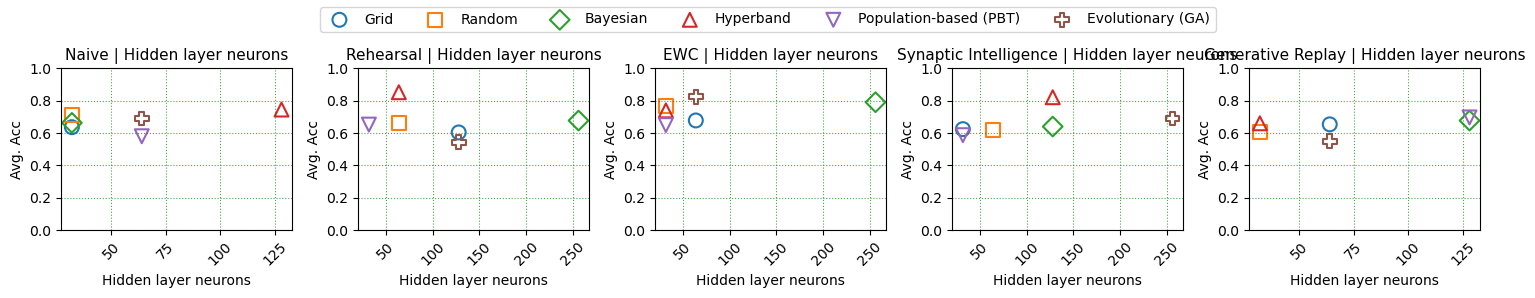

Saved gat_dynamic_hpo_LR.pdf


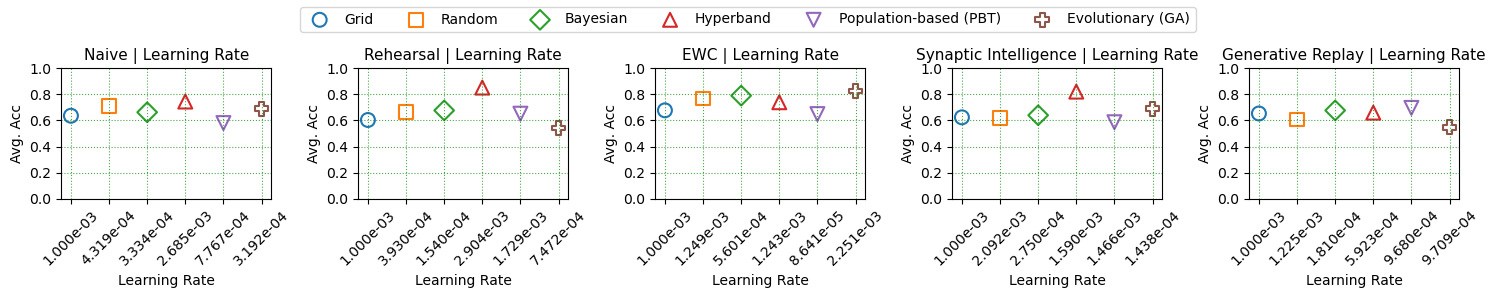

Saved gat_dynamic_hpo_WD.pdf


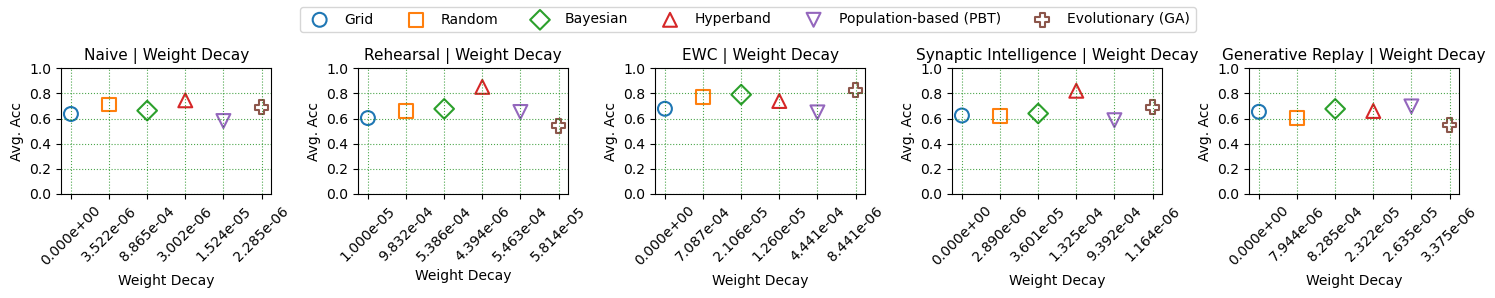

Saved gat_dynamic_hpo_Heads.pdf


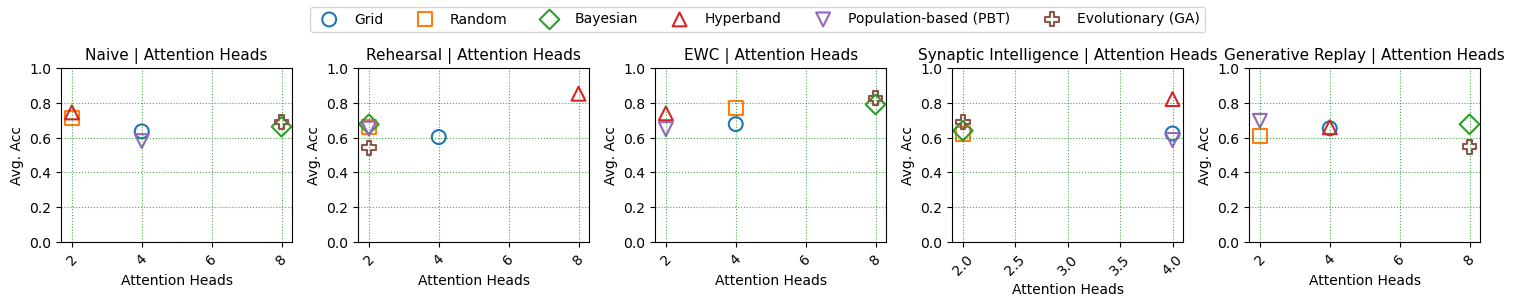

Saved gat_dynamic_hpo_Dropout.pdf


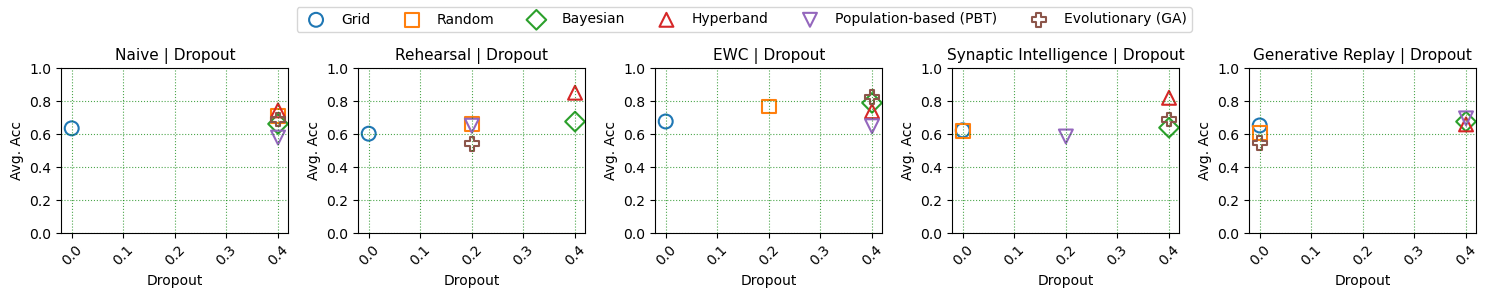

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np

# Methods, colors, and markers
methods = summary_df["Search"].unique()
palette = sns.color_palette("tab10", n_colors=len(methods))
method_colors = dict(zip(methods, palette))
marker_styles = ["o", "s", "D", "^", "v", "P", "X", "*"]
method_markers = dict(zip(methods, marker_styles))

def pretty_param_label(param):
    if param == "HiddenDim": return "Hidden layer neurons"
    if param == "LR": return "Learning Rate"
    if param == "WD": return "Weight Decay"
    if param == "ewc_lam": return "EWC ?"
    if param == "si_c": return "SI c"
    if param == "Dropout": return "Dropout"
    if param == "Heads": return "Attention Heads"
    return param

# Mechanism pretty names
mech_map = {
    "naive": "Naive",
    "rehearsal": "Rehearsal",
    "ewc": "EWC",
    "si": "Synaptic Intelligence",
    "gen_replay": "Generative Replay"
}

# Hyperparameters to plot (matching summary_df columns)
hyperparams = ["HiddenDim", "LR", "WD", "Heads", "Dropout"]

for param in hyperparams:
    fig, axes = plt.subplots(1, len(MECHANISMS), figsize=(3*len(MECHANISMS), 3), squeeze=False)

    if param in summary_df.columns:
        tested_vals = sorted(summary_df[param].dropna().unique())
    else:
        tested_vals = []

    for j, mech in enumerate(MECHANISMS):
        ax = axes[0, j]
        df_mech = summary_df[summary_df["Mechanism"] == mech]

        if param in df_mech.columns and len(tested_vals) > 0:
            for method in methods:
                df_m = df_mech[df_mech["Search"] == method]
                for xval in tested_vals:
                    df_x = df_m[df_m[param] == xval]
                    if len(df_x) == 0:
                        continue
                    # Convert "Avg final acc" string to float
                    df_x["AvgAccFloat"] = df_x["Avg final acc"].str.rstrip("%").astype(float)/100.0
                    best_row = df_x.loc[df_x["AvgAccFloat"].idxmax()]
                    ax.scatter(
                        [best_row[param]], [best_row["AvgAccFloat"]],
                        label=method,
                        marker=method_markers[method],
                        facecolors='none',
                        edgecolors=method_colors[method],
                        s=100, linewidths=1.5
                    )

        # Axis styling
        param_label = pretty_param_label(param)
        ax.set_title(f"{mech_map.get(mech, mech)} | {param_label}", fontsize=11)
        ax.set_xlabel(param_label)
        ax.set_ylabel("Avg. Acc")
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        '''
        if param in ["LR", "WD"]:
            ax.set_xticks(tested_vals)
            ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x}"))
        else:
            ax.set_xticks(tested_vals)
        '''
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, linestyle=':', color='green', alpha=0.7)

    handles, labels = axes[0, -1].get_legend_handles_labels()
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    fig.legend(list(uniq.values()), list(uniq.keys()), loc="upper center", ncol=len(methods))

    plt.tight_layout(rect=[0,0,1,0.9])
    filename = f"gat_dynamic_hpo_{param}.pdf"
    plt.savefig(filename, format="pdf")
    print(f"Saved {filename}")
    plt.show()


In [4]:
import pprint

# Mechanisms of interest
mechanisms = ["naive", "rehearsal", "ewc", "si", "gen_replay"]

# Pretty printer
pp = pprint.PrettyPrinter(indent=2)

# Explicit batch accuracy columns (static summary uses TaskX acc)
batch_acc_cols = [f"Task{i} acc" for i in range(6)]

# Hyperparameter columns (matching summary_df)
hyperparam_cols = ["HiddenDim", "LR", "WD", "Heads", "Dropout", "ewc_lam", "si_c"]

for mech in mechanisms:
    df_mech = summary_df[summary_df["Mechanism"] == mech]
    if df_mech.empty:
        print(f"\n=== No data for {mech} ===")
        continue
    
    # Convert Avg final acc to numeric for comparison
    df_mech["AvgAccFloat"] = df_mech["Avg final acc"].str.rstrip("%").astype(float)
    best_row = df_mech.loc[df_mech["AvgAccFloat"].idxmax()]
    
    # Collect batch accuracies
    batch_accs = {col: best_row[col] for col in batch_acc_cols if col in best_row}
    
    # Collect hyperparameters
    hyperparams = {col: best_row[col] for col in hyperparam_cols if col in best_row}
    
    # Build dictionary
    best_config = {
        "Mechanism": mech.capitalize(),
        "Search Method": best_row["Search"],
        "Avg Accuracy": best_row["Avg final acc"],
        "Batch Accuracies": batch_accs,
        "Hyperparameters": hyperparams
    }
    
    print(f"\n=== Best configuration for {mech.upper()} ===")
    pp.pprint(best_config)



=== Best configuration for NAIVE ===
{ 'Avg Accuracy': '74.50%',
  'Batch Accuracies': { 'Task0 acc': '76.75%',
                        'Task1 acc': '72.50%',
                        'Task2 acc': '73.38%',
                        'Task3 acc': '74.24%',
                        'Task4 acc': '76.20%',
                        'Task5 acc': '73.91%'},
  'Hyperparameters': { 'Dropout': np.float64(0.4),
                       'Heads': np.int64(2),
                       'HiddenDim': np.int64(128),
                       'LR': '2.685e-03',
                       'WD': '3.002e-06'},
  'Mechanism': 'Naive',
  'Search Method': 'Hyperband'}

=== Best configuration for REHEARSAL ===
{ 'Avg Accuracy': '85.22%',
  'Batch Accuracies': { 'Task0 acc': '81.62%',
                        'Task1 acc': '86.38%',
                        'Task2 acc': '87.12%',
                        'Task3 acc': '84.85%',
                        'Task4 acc': '84.42%',
                        'Task5 acc': '86.96%'},
  'Hyperpa